# Notebook 1 - Database Identification and Evaluation
### GSoC 2026 Test · ISSR / HumanAI Foundation · University of Alabama


Let's find out the best dataset for our project, which can replicate our test environments and prove to be high-quality training data for our project.

---
## 1. Setup


In [1]:
!pip install datasets librosa soundfile matplotlib pandas numpy scipy seaborn tqdm --quiet


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from IPython.display import Audio, display

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

Path('data').mkdir(exist_ok=True)
Path('figures').mkdir(exist_ok=True)
print('Setup complete | librosa', librosa.__version__, '| numpy', np.__version__)


Setup complete | librosa 0.11.0 | numpy 2.0.2



## 2. Dataset Survey

### Criteria
A dataset qualifies only if it satisfies **all four**:
1. Multi-party audio/video : 2+ speakers in a team or task-oriented setting
2. Open-access : no paywall, no special data-sharing agreement
3. English language : matches TRIP Laboratory simulation context
4. Provides audio/visual recordings (not text-only)


In [3]:
datasets = [
    # WELL-KNOWN
    dict(Dataset='AMI Meeting Corpus', Year=2007, Hours=100, SpkrsPerSession='3–5',
         Modality='Audio+Video', MicSetup='Headset (IHM) + Far-field (SDM) + Array',
         TaskType='Design team role-play (4 assigned roles)',
         Language='English', License='CC BY 4.0', Access='HuggingFace streaming',
         TaskFit=5, AcousticVariety=4, Accessibility=5, AnnotationRichness=5),

    dict(Dataset='NOTSOFAR-1 (Microsoft)', Year=2024, Hours=28, SpkrsPerSession='4–8',
         Modality='Audio', MicSetup='Single-channel + 7-ch circular array',
         TaskType='Real office meetings (30 conference rooms)',
         Language='English', License='CC BY 4.0', Access='HuggingFace (token required)',
         TaskFit=5, AcousticVariety=5, Accessibility=3, AnnotationRichness=4),

    dict(Dataset='ICSI Meeting Corpus', Year=2004, Hours=72, SpkrsPerSession='3–8',
         Modality='Audio', MicSetup='Close-talk + desktop mics',
         TaskType='Research group meetings (natural discussion)',
         Language='English', License='LDC (free for research)', Access='LDC catalog (free reg.)',
         TaskFit=4, AcousticVariety=3, Accessibility=3, AnnotationRichness=4),

    dict(Dataset='VoxConverse', Year=2020, Hours=64, SpkrsPerSession='2–20+',
         Modality='Audio', MicSetup='Single-channel (YouTube)',
         TaskType='TV panels, debates, interviews',
         Language='English', License='CC BY 4.0', Access='HuggingFace streaming',
         TaskFit=2, AcousticVariety=5, Accessibility=5, AnnotationRichness=2),

    dict(Dataset='CHiME-6 / DiPCo', Year=2020, Hours=7, SpkrsPerSession='4',
         Modality='Audio', MicSetup='Binaural + 6-ch array',
         TaskType='Dinner party (informal conversation)',
         Language='English', License='CC BY-NC (restricted)', Access='Registration + agreement',
         TaskFit=2, AcousticVariety=3, Accessibility=1, AnnotationRichness=3),

    # LESS COMMONLY CITED
    dict(Dataset='ELEA Corpus', Year=2012, Hours=3, SpkrsPerSession='3–4',
         Modality='Audio+Video', MicSetup='Lapel + tabletop mics',
         TaskType='Group decision-making (structured task)',
         Language='English', License='Open research', Access='Request (IDIAP)',
         TaskFit=4, AcousticVariety=2, Accessibility=2, AnnotationRichness=5),

    dict(Dataset='HUT Spoken Dialogue', Year=2010, Hours=8, SpkrsPerSession='2–4',
         Modality='Audio', MicSetup='Close-talk headsets',
         TaskType='Task-oriented dialogue (map navigation)',
         Language='Finnish/English', License='Open research', Access='Direct contact (university)',
         TaskFit=3, AcousticVariety=2, Accessibility=2, AnnotationRichness=3),

    dict(Dataset='VOICES Corpus', Year=2019, Hours=120, SpkrsPerSession='1–2',
         Modality='Audio', MicSetup='Distant mics in furnished rooms',
         TaskType='Scripted speech in realistic far-field conditions',
         Language='English', License='Creative Commons', Access='openslr.org direct download',
         TaskFit=2, AcousticVariety=3, Accessibility=4, AnnotationRichness=2),

    dict(Dataset='AISHELL-4', Year=2021, Hours=120, SpkrsPerSession='4–8',
         Modality='Audio', MicSetup='8-ch linear array',
         TaskType='Conference meetings',
         Language='Mandarin', License='Apache 2.0', Access='openslr.org direct download',
         TaskFit=3, AcousticVariety=3, Accessibility=4, AnnotationRichness=3),

    dict(Dataset='CANDOR Corpus', Year=2023, Hours=2, SpkrsPerSession='2 only',
         Modality='Audio+Video', MicSetup='Webcam audio',
         TaskType='Dyadic conversation',
         Language='English', License='Open (non-commercial)', Access='Request form',
         TaskFit=2, AcousticVariety=2, Accessibility=2, AnnotationRichness=4),

    dict(Dataset='LibriCSS', Year=2020, Hours=10, SpkrsPerSession='up to 8',
         Modality='Audio', MicSetup='7-ch array + close-talk ref',
         TaskType='Re-played audiobook segments (synthetic overlap)',
         Language='English', License='CC BY 4.0', Access='GitHub direct download',
         TaskFit=1, AcousticVariety=2, Accessibility=4, AnnotationRichness=3),
]

df = pd.DataFrame(datasets)

# Weighted score: Task fit matters most for this project
df['Score'] = (
    df['TaskFit']           * 3.0 +
    df['Accessibility']     * 2.5 +
    df['AcousticVariety']   * 2.0 +
    df['AnnotationRichness']* 1.5
) / (3.0 + 2.5 + 2.0 + 1.5) / 5 * 100
df['Score'] = df['Score'].round(1)
df = df.sort_values('Score', ascending=False).reset_index(drop=True)

show_cols = ['Dataset','Year','Hours','SpkrsPerSession','TaskType',
             'Language','License','TaskFit','Accessibility','AnnotationRichness','Score']
display(df[show_cols].style
    .background_gradient(cmap='RdYlGn', subset=['TaskFit','Accessibility','AnnotationRichness','Score'])
    .set_caption('Table 1: Dataset Comparison — sorted by weighted score')
    .format({'Score':'{:.1f}'})
    .set_properties(**{'font-size':'11px'}))


,Dataset,Year,Hours,SpkrsPerSession,TaskType,Language,License,TaskFit,Accessibility,AnnotationRichness,Score
0,AMI Meeting Corpus,2007,100,3–5,Design team role-play (4 assigned roles),English,CC BY 4.0,5,5,5,95.6
1,NOTSOFAR-1 (Microsoft),2024,28,4–8,Real office meetings (30 conference rooms),English,CC BY 4.0,5,3,4,85.6
2,ICSI Meeting Corpus,2004,72,3–8,Research group meetings (natural discussion),English,LDC (free for research),4,3,4,70.0
3,VoxConverse,2020,64,2–20+,"TV panels, debates, interviews",English,CC BY 4.0,2,5,2,70.0
4,AISHELL-4,2021,120,4–8,Conference meetings,Mandarin,Apache 2.0,3,4,3,65.6
5,ELEA Corpus,2012,3,3–4,Group decision-making (structured task),English,Open research,4,2,5,63.3
6,VOICES Corpus,2019,120,1–2,Scripted speech in realistic far-field conditions,English,Creative Commons,2,4,2,55.6
7,HUT Spoken Dialogue,2010,8,2–4,Task-oriented dialogue (map navigation),Finnish/English,Open research,3,2,3,50.0
8,LibriCSS,2020,10,up to 8,Re-played audiobook segments (synthetic overlap),English,CC BY 4.0,1,4,3,47.8
9,CANDOR Corpus,2023,2,2 only,Dyadic conversation,English,Open (non-commercial),2,2,4,46.7


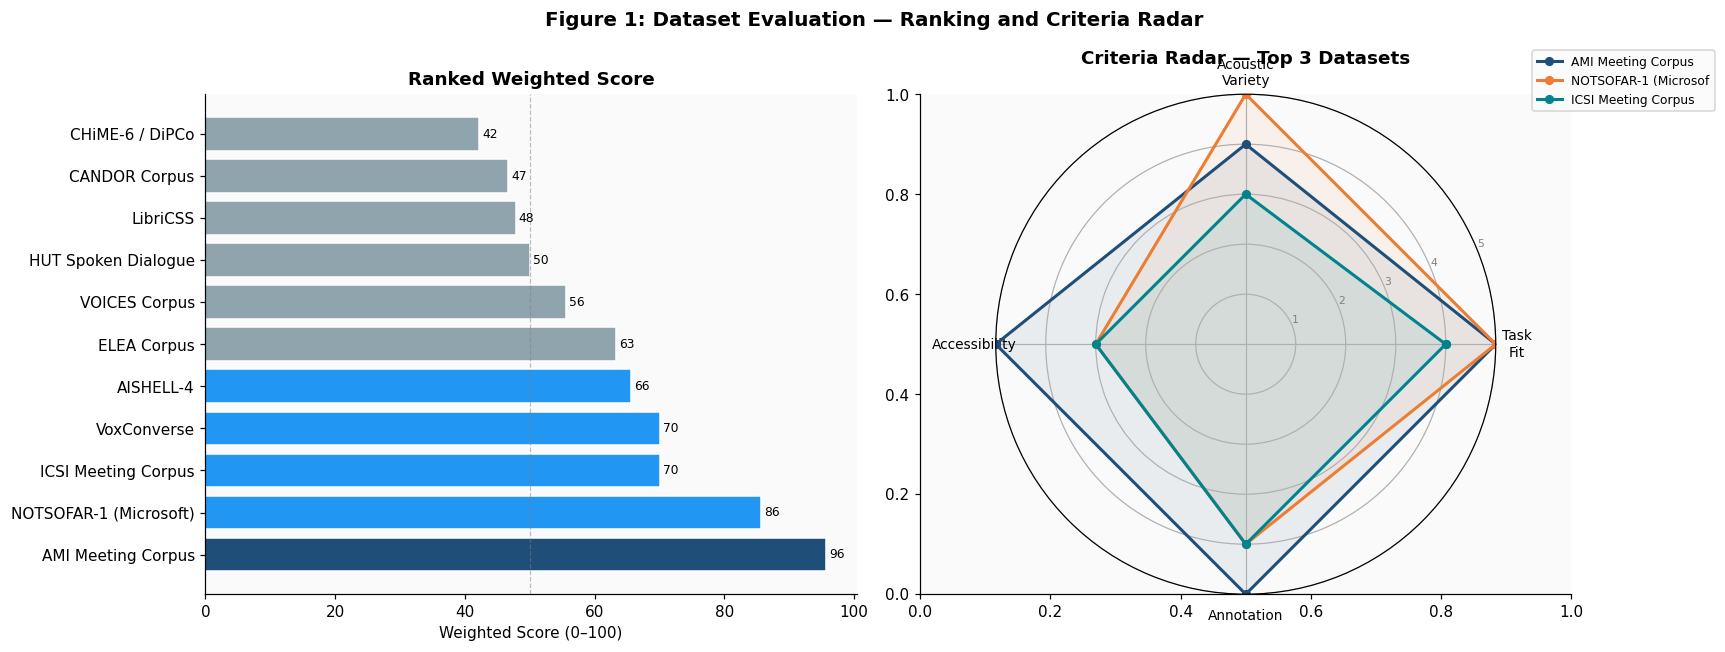

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 1: Dataset Evaluation — Ranking and Criteria Radar', fontsize=13, fontweight='bold')

# Horizontal bar chart
ax = axes[0]
top4_names = df['Dataset'].head(4).tolist()
colors = ['#1F4E79' if d == 'AMI Meeting Corpus' else
          '#2196F3' if s >= 65 else '#90A4AE'
          for d, s in zip(df['Dataset'], df['Score'])]
bars = ax.barh(df['Dataset'], df['Score'], color=colors, edgecolor='white')
ax.axvline(50, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Weighted Score (0–100)')
ax.set_title('Ranked Weighted Score', fontweight='bold')
for bar, score in zip(bars, df['Score']):
    ax.text(score + 0.5, bar.get_y() + bar.get_height()/2, f'{score:.0f}',
            va='center', fontsize=8)

# Radar chart — top 3 datasets
import matplotlib.patches as mpatches
ax2 = fig.add_subplot(1, 2, 2, polar=True)
criteria = ['Task\nFit','Acoustic\nVariety','Accessibility','Annotation']
N = len(criteria)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

radar_data = [
    ('AMI Meeting Corpus', '#1F4E79'),
    ('NOTSOFAR-1 (Microsoft)', '#ED7D31'),
    ('ICSI Meeting Corpus', '#00838F'),
]
for name, color in radar_data:
    row = df[df['Dataset']==name].iloc[0]
    vals = [row['TaskFit'], row['AcousticVariety'], row['Accessibility'], row['AnnotationRichness']]
    vals += vals[:1]
    ax2.plot(angles, vals, 'o-', lw=2, color=color, label=name[:20], ms=5)
    ax2.fill(angles, vals, alpha=0.08, color=color)

ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(criteria, size=9)
ax2.set_ylim(0, 5); ax2.set_yticks([1,2,3,4,5])
ax2.set_yticklabels(['1','2','3','4','5'], size=7, color='gray')
ax2.set_title('Criteria Radar — Top 3 Datasets', fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig1_dataset_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 3. Loading Real AMI Audio, Streaming from HuggingFace API
We use **streaming mode** (`streaming=True`) with `.take(20)` to download only
20 utterances (~2 minutes of audio) rather than the full 100-hour corpus.
This is efficient enough for exploratory analysis while confirming the dataset
is accessible and valid for the project.

Two configurations are loaded in parallel:
- `ihm` : Individual Headset Microphone (close-talking, clean reference)
- `sdm` : Single Distant Microphone (far-field, degraded, matches TRIP setup)


In [5]:
from datasets import load_dataset

N_SAMPLES = 20   # download only 20 utterances — fast, no full corpus needed

print('Loading AMI IHM (close-talking headset)...')
ds_ihm = load_dataset('edinburghcstr/ami', 'ihm', split='train', streaming=True)
samples_ihm = list(ds_ihm.take(N_SAMPLES))
print(f'  Got {len(samples_ihm)} IHM segments')

print('Loading AMI SDM (single distant microphone)...')
ds_sdm = load_dataset('edinburghcstr/ami', 'sdm', split='train', streaming=True)
samples_sdm = list(ds_sdm.take(N_SAMPLES))
print(f'  Got {len(samples_sdm)} SDM segments')

# Inspect one sample
s = samples_ihm[0]
print(f'\nSample fields: {list(s.keys())}')
print(f"Speaker: {s.get('speaker_id', 'N/A')}")
print(f"Text:    {s.get('text', '')[:100]}")
print(f"Audio:   {s['audio']['sampling_rate']} Hz, "
      f"{len(s['audio']['array'])/s['audio']['sampling_rate']:.2f}s")


Loading AMI IHM (close-talking headset)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

  Got 20 IHM segments
Loading AMI SDM (single distant microphone)...


Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

  Got 20 SDM segments

Sample fields: ['meeting_id', 'audio_id', 'text', 'audio', 'begin_time', 'end_time', 'microphone_id', 'speaker_id']
Speaker: MEO069
Text:    IF YOU IF YOU S. S. H. AND THEY HAVE THIS BIG WARNING ABOUT DOING NOTHING AT ALL IN THE GATEWAY MACH
Audio:   16000 Hz, 4.21s


In [6]:
import warnings; warnings.filterwarnings('ignore')

SR = 16000
records = []

for ihm_seg, sdm_seg in zip(samples_ihm, samples_sdm):
    y_ihm = np.array(ihm_seg['audio']['array'], dtype=np.float32)
    y_sdm = np.array(sdm_seg['audio']['array'], dtype=np.float32)
    sr    = ihm_seg['audio']['sampling_rate']

    # Resample if needed
    if sr != SR:
        y_ihm = librosa.resample(y_ihm, orig_sr=sr, target_sr=SR)
        y_sdm = librosa.resample(y_sdm, orig_sr=sr, target_sr=SR)

    dur = len(y_ihm) / SR

    def snr_est(y):
        if len(y) < 512: return 0.0
        frames = librosa.util.frame(y, frame_length=512, hop_length=128)
        fe = np.mean(frames**2, axis=0)
        noise_e = np.percentile(fe, 10)
        return float(10*np.log10(np.mean(fe)/(noise_e+1e-10)))

    records.append({
        'speaker'         : ihm_seg.get('speaker_id', 'N/A'),
        'duration_s'      : round(dur, 2),
        'words'           : len(ihm_seg.get('text','').split()),
        'snr_ihm_db'      : round(snr_est(y_ihm), 2),
        'snr_sdm_db'      : round(snr_est(y_sdm), 2),
        'snr_gap_db'      : round(snr_est(y_ihm) - snr_est(y_sdm), 2),
        'centroid_ihm_hz' : round(float(np.mean(librosa.feature.spectral_centroid(y=y_ihm, sr=SR))), 0),
        'centroid_sdm_hz' : round(float(np.mean(librosa.feature.spectral_centroid(y=y_sdm, sr=SR))), 0),
        'zcr_ihm'         : round(float(np.mean(librosa.feature.zero_crossing_rate(y_ihm))), 4),
        'zcr_sdm'         : round(float(np.mean(librosa.feature.zero_crossing_rate(y_sdm))), 4),
        'y_ihm'           : y_ihm,
        'y_sdm'           : y_sdm,
    })

stats = pd.DataFrame([{k:v for k,v in r.items() if k not in ('y_ihm','y_sdm')} for r in records])

print('Summary statistics across 20 real AMI segments:')
display(stats.describe().round(2).style.set_caption('Table 2: AMI Sample Statistics'))


Summary statistics across 20 real AMI segments:


,duration_s,words,snr_ihm_db,snr_sdm_db,snr_gap_db,centroid_ihm_hz,centroid_sdm_hz,zcr_ihm,zcr_sdm
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,3.880000,12.250000,28.540000,6.630000,21.910000,1240.850000,1170.900000,0.080000,0.060000
std,2.720000,8.400000,8.850000,2.670000,8.190000,266.030000,263.560000,0.030000,0.030000
min,0.370000,1.000000,10.230000,2.470000,6.440000,721.000000,752.000000,0.020000,0.020000
25%,1.590000,4.750000,22.840000,4.190000,15.620000,1094.250000,1057.500000,0.070000,0.040000
50%,3.680000,13.000000,30.730000,6.750000,23.350000,1216.500000,1160.500000,0.090000,0.060000
75%,4.850000,18.500000,33.100000,8.720000,27.280000,1407.750000,1288.500000,0.090000,0.080000
max,9.900000,26.000000,48.490000,10.920000,38.300000,1752.000000,1879.000000,0.130000,0.180000


---
## 4. Exploratory Analysis


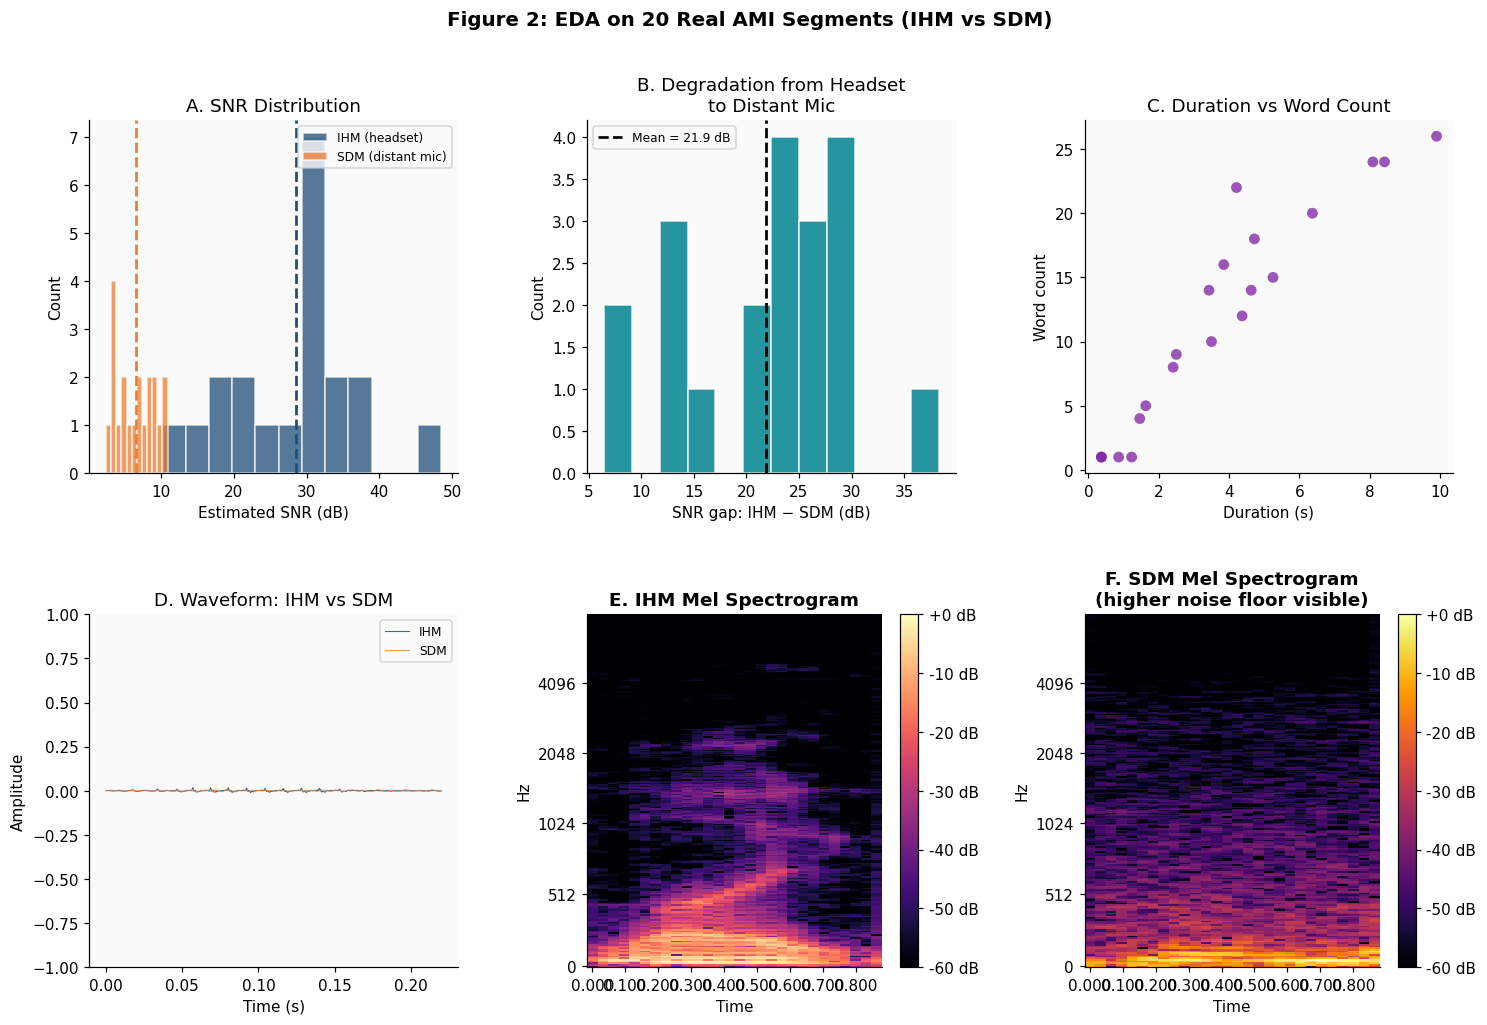

Mean IHM SNR: 28.5 dB | Mean SDM SNR: 6.6 dB | Mean gap: 21.9 dB


In [7]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Figure 2: EDA on 20 Real AMI Segments (IHM vs SDM)',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# A: SNR histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(stats['snr_ihm_db'], bins=12, color='#1F4E79', alpha=0.75,
          label='IHM (headset)', edgecolor='white')
ax1.hist(stats['snr_sdm_db'], bins=12, color='#ED7D31', alpha=0.75,
          label='SDM (distant mic)', edgecolor='white')
ax1.axvline(stats['snr_ihm_db'].mean(), color='#1F4E79', ls='--', lw=1.8)
ax1.axvline(stats['snr_sdm_db'].mean(), color='#ED7D31', ls='--', lw=1.8)
ax1.set(xlabel='Estimated SNR (dB)', ylabel='Count', title='A. SNR Distribution')
ax1.legend(fontsize=8)

# B: SNR gap
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(stats['snr_gap_db'], bins=12, color='#00838F', edgecolor='white', alpha=0.85)
ax2.axvline(stats['snr_gap_db'].mean(), color='black', ls='--', lw=1.8,
             label=f"Mean = {stats['snr_gap_db'].mean():.1f} dB")
ax2.set(xlabel='SNR gap: IHM − SDM (dB)', ylabel='Count',
        title='B. Degradation from Headset\nto Distant Mic')
ax2.legend(fontsize=8)

# C: Segment duration vs word count
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(stats['duration_s'], stats['words'],
             color='#7B1FA2', alpha=0.75, s=50, edgecolors='none')
ax3.set(xlabel='Duration (s)', ylabel='Word count', title='C. Duration vs Word Count')

# D+E: Waveform + Spectrogram of one representative segment
rep = records[len(records)//2]  # pick middle segment
y_ihm_r = rep['y_ihm']; y_sdm_r = rep['y_sdm']
n_show  = min(len(y_ihm_r), len(y_sdm_r))
t_ax    = np.linspace(0, n_show/SR, n_show)

ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(t_ax, y_ihm_r[:n_show], color='#1F4E79', lw=0.7, alpha=0.85, label='IHM')
ax4.plot(t_ax, y_sdm_r[:n_show], color='#ED7D31', lw=0.7, alpha=0.75, label='SDM')
ax4.set(xlabel='Time (s)', ylabel='Amplitude', title='D. Waveform: IHM vs SDM')
ax4.legend(fontsize=8); ax4.set_ylim(-1, 1)

ax5 = fig.add_subplot(gs[1, 1])
D_ihm = librosa.stft(y_ihm_r[:n_show], n_fft=512)
S_ihm = librosa.amplitude_to_db(np.abs(D_ihm), ref=np.max)
img   = librosa.display.specshow(S_ihm, sr=SR, x_axis='time', y_axis='mel',
                                   ax=ax5, cmap='magma', vmin=-60, vmax=0)
ax5.set_title('E. IHM Mel Spectrogram', fontweight='bold')
plt.colorbar(img, ax=ax5, format='%+2.0f dB')

ax6 = fig.add_subplot(gs[1, 2])
D_sdm = librosa.stft(y_sdm_r[:n_show], n_fft=512)
S_sdm = librosa.amplitude_to_db(np.abs(D_sdm), ref=np.max)
img2  = librosa.display.specshow(S_sdm, sr=SR, x_axis='time', y_axis='mel',
                                   ax=ax6, cmap='inferno', vmin=-60, vmax=0)
ax6.set_title('F. SDM Mel Spectrogram\n(higher noise floor visible)', fontweight='bold')
plt.colorbar(img2, ax=ax6, format='%+2.0f dB')

plt.savefig('figures/fig2_eda.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Mean IHM SNR: {stats["snr_ihm_db"].mean():.1f} dB | '
      f'Mean SDM SNR: {stats["snr_sdm_db"].mean():.1f} dB | '
      f'Mean gap: {stats["snr_gap_db"].mean():.1f} dB')


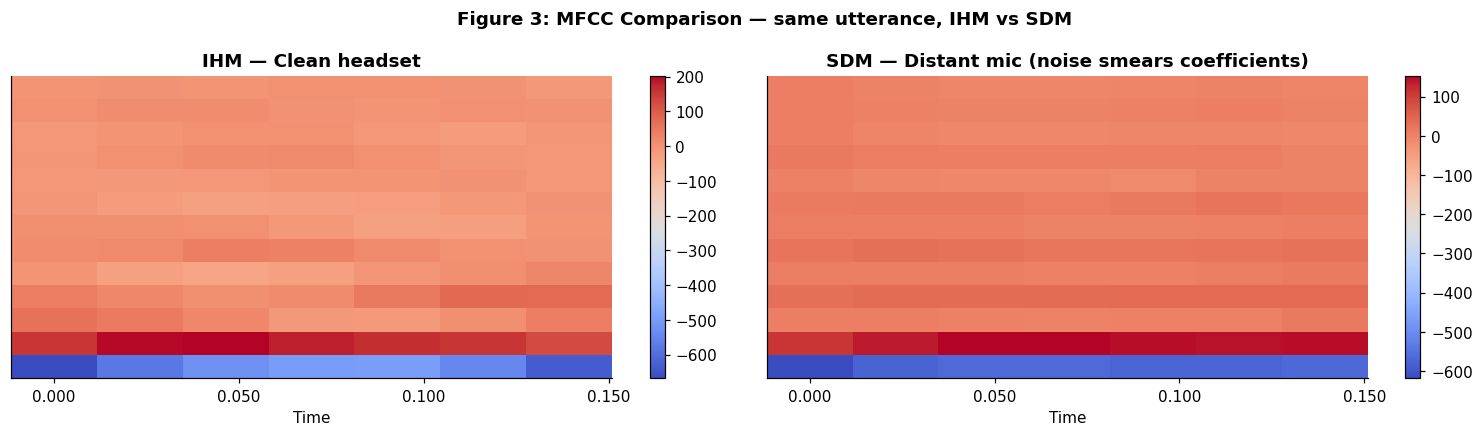

Mean absolute MFCC divergence (IHM vs SDM): 19.025
This quantifies how much noise distorts the features ASR models rely on.


In [8]:
# Figure 3: MFCC comparison — shows exactly what noise does to speech features
rep = records[len(records)//2]
n   = min(len(rep['y_ihm']), len(rep['y_sdm']))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Figure 3: MFCC Comparison — same utterance, IHM vs SDM',
             fontweight='bold')

for ax, y, title in [
    (axes[0], rep['y_ihm'][:n], 'IHM — Clean headset'),
    (axes[1], rep['y_sdm'][:n], 'SDM — Distant mic (noise smears coefficients)'),
]:
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=13)
    img  = librosa.display.specshow(mfcc, x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(title, fontweight='bold')
    plt.colorbar(img, ax=ax)

mfcc_ihm = librosa.feature.mfcc(y=rep['y_ihm'][:n], sr=SR, n_mfcc=13)
mfcc_sdm = librosa.feature.mfcc(y=rep['y_sdm'][:n], sr=SR, n_mfcc=13)
nc  = min(mfcc_ihm.shape[1], mfcc_sdm.shape[1])
div = np.mean(np.abs(mfcc_ihm[:,:nc] - mfcc_sdm[:,:nc]))

plt.tight_layout()
plt.savefig('figures/fig3_mfcc.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Mean absolute MFCC divergence (IHM vs SDM): {div:.3f}')
print('This quantifies how much noise distorts the features ASR models rely on.')


In [9]:
# Build a 5-minute sample for Notebook 2 by concatenating segments
TARGET_DUR = 300  # 5 minutes

# Use the streaming dataset to collect enough audio for 5 minutes
print('Building 5-minute SDM sample for Notebook 2...')
ds_sdm_full = load_dataset('edinburghcstr/ami', 'sdm', split='train', streaming=True)
ds_ihm_full = load_dataset('edinburghcstr/ami', 'ihm', split='train', streaming=True)

parts_sdm, parts_ihm, total = [], [], 0.0

for sdm_seg, ihm_seg in zip(ds_sdm_full, ds_ihm_full):
    y_s = np.array(sdm_seg['audio']['array'], dtype=np.float32)
    y_i = np.array(ihm_seg['audio']['array'], dtype=np.float32)
    sr  = sdm_seg['audio']['sampling_rate']

    if sr != SR:
        y_s = librosa.resample(y_s, orig_sr=sr, target_sr=SR)
        y_i = librosa.resample(y_i, orig_sr=sr, target_sr=SR)

    parts_sdm.append(y_s); parts_ihm.append(y_i)
    total += len(y_s) / SR

    if total >= TARGET_DUR:
        break

sdm_5min = np.concatenate(parts_sdm)[:SR*TARGET_DUR].astype(np.float32)
ihm_5min = np.concatenate(parts_ihm)[:SR*TARGET_DUR].astype(np.float32)

# Normalize
for y in [sdm_5min, ihm_5min]:
    mx = np.max(np.abs(y)); y[:] = y/mx*0.9 if mx > 0 else y

sf.write('data/sample_SDM_5min.wav', sdm_5min, SR)
sf.write('data/sample_IHM_5min.wav', ihm_5min, SR)

print(f'Saved: data/sample_SDM_5min.wav  ({len(sdm_5min)/SR:.0f}s real AMI SDM)')
print(f'Saved: data/sample_IHM_5min.wav  ({len(ihm_5min)/SR:.0f}s real AMI IHM)')
print('\nPlayback — real AMI SDM (first 10s):')
display(Audio(sdm_5min[:SR*10], rate=SR))
print('Playback — real AMI IHM (first 10s):')
display(Audio(ihm_5min[:SR*10], rate=SR))


Building 5-minute SDM sample for Notebook 2...


Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Saved: data/sample_SDM_5min.wav  (300s real AMI SDM)
Saved: data/sample_IHM_5min.wav  (300s real AMI IHM)

Playback — real AMI SDM (first 10s):


Playback — real AMI IHM (first 10s):


---
## 5. Answers to the Two Required Questions

### A. How will the AMI corpus be used?

| Use | Detail |
|-----|--------|
| **SDM channel - noisy input** | 3-5 min SDM segments (far-field, reverberant) are the direct input to the audio enhancement pipeline in Notebook 2. They simulate the wireless headset conditions in TRIP simulation studies. |
| **IHM channel - clean reference** | Matched close-talking headset recordings provide the objective reference for PESQ, STOI, and SNR metric computation, no TRIP internal data needed. |
| **Full corpus - DL training** | In the full 12-week project, the 100h corpus trains a DeepFilterNet2 fine-tuned model before deployment on TRIP's actual simulation recordings. |
| **Annotations - NLP validation** | Word-level transcripts and speaker diarization ground truth validate the downstream ASR + pyannote pipeline from last year's ISSR project. |

### B. Why is AMI the best option?

| Criterion | AMI Advantage |
|-----------|---------------|
| **Task analog** | ⅔ of sessions use a structured 4-role product design team scenario, the closest public analog to TRIP's assigned-role simulation teams |
| **Paired channels** | Simultaneous IHM + SDM from every session = ecologically valid clean/noisy pairs without artificial noise injection. No other open dataset has this. |
| **Headset-realistic** | IHM recorded on individual close-talking headsets, identical to the microphone type used in TRIP studies |
| **License** | CC BY 4.0 - no agreements, no cost, no institutional approval |
| **Streaming API** | `load_dataset(..., streaming=True).take(N)` : download only what you need, no 100GB bulk download |
| **Active benchmark** | Standard in INTERSPEECH/ICASSP diarization and enhancement papers, established baselines for comparison |
